In [101]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

## Linear Regression from the Normal Equation
You can analytically solve for the weights using the normal equation.
$$\hat{\mathbf{w}} = \left(\mathbf{X}^{\top}\mathbf{X}\right)^{-1}\mathbf{X}^{\top}\mathbf{y}$$

In [ ]:
def add_bias(X):
    """
    Joins a column of ones to X. This represents the bias/intercept.
    """
    m = X.shape[0]
    bias = np.ones((m, 1))
    X = np.hstack((bias, X))

    return X

def normal_equation(X, y):
    """
    Gives the thetaeights from solving the normal equation.
    """
    theta = np.linalg.inv(X.T @ X) @ X.T @ y

    return theta

## Linear Regression from Gradient Descent

Using a cost function and gradient descent, weights can be found iteratively.

The cost function for linear regression is:
$$J(\mathbf{w}) = \frac{1}{2m}\sum_{i=1}^{m}\left(\hat{y}^{(i)} - y^{(i)}\right)^{2}$$

The cost function is calculated per data point and summed up together

The gradient is as follows. 
If the intercept is included in X then only the partial derivative with respect to w is needed (no need for update for b)

$$\frac{\partial J}{\partial w_j} = \frac{1}{m}\sum_{i=1}^{m}\left(\hat{y}^{(i)} - y^{(i)}\right)x_j^{(i)}$$

In [ ]:
def compute_cost(X, y, theta):
    """
    Computes the cost function for linear regression.
    J = (1/2m) * ||Xtheta - y||^2
    """
    m = X.shape[0]

    J = (1 / (2*m)) * np.sum((X @ theta - y) ** 2)
    return J

def gradient_descent(X, y, lr=0.01, n_iter=1000):
    """
    Performs gradient descent
    """
    m, n = X.shape

    # initalize thetaeights to be 0
    theta = np.zeros(n)
    history = []

    for i in range(n_iter):
        grad = (1/m) * (X.T @ (X @ theta - y))
        theta -= grad * lr
        history.append(compute_cost(X, y, theta))    
    return theta, np.array(history)


## Comparison

In [ ]:
def predict(X, theta):
    """
    Computes predictions using thetaeights and data
    """
    yhat = X @ theta

    return yhat

def rmse(yhat, y):
    """
    Compute root mean squared error.
    """
    error = np.sqrt(np.mean((yhat - y) ** 2))
    return np.sum(error)

In [ ]:
# Creates linear data
TRUE_BIAS = 50
X, y, coef = make_regression(n_samples = 200, n_features=3, bias= TRUE_BIAS, noise=0, coef=True, random_state =42)

Xb = add_bias(X)

# Normal Equation
theta_normal  = normal_equation(Xb, y)
yhat_normal = predict(Xb, theta_normal)
rmse_normal = rmse(yhat_normal, y)

# Gradient Descent
theta_grad, history = gradient_descent(Xb, y, lr=5, n_iter=5000)
yhat_grad = predict(Xb, theta_grad)
rmse_grad = rmse(yhat_grad, y)

# Scikit-learn
model = LinearRegression().fit(X, y)
yhat_sci = model.predict(X)
rmse_sci = rmse(yhat_sci, y)
theta_sci = model.coef_
intercept_sci = model.intercept_

c:\Users\towen\anaconda3\envs\ml\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\towen\AppData\Local\Temp\ipykernel_22756\4049076245.py:8: RuntimeWarning: overflow encountered in square
  J = (1 / (2*m)) * np.sum((X @ w - y) ** 2)
C:\Users\towen\AppData\Local\Temp\ipykernel_22756\4049076245.py:22: RuntimeWarning: overflow encountered in matmul
  grad = (1/m) * (X.T @ (X @ w - y))
C:\Users\towen\AppData\Local\Temp\ipykernel_22756\4049076245.py:8: RuntimeWarning: invalid value encountered in matmul
  J = (1 / (2*m)) * np.sum((X @ w - y) ** 2)
C:\Users\towen\AppData\Local\Temp\ipykernel_22756\4049076245.py:22: RuntimeWarning: invalid value encountered in matmul
  grad = (1/m) * (X.T @ (X @ w - y))


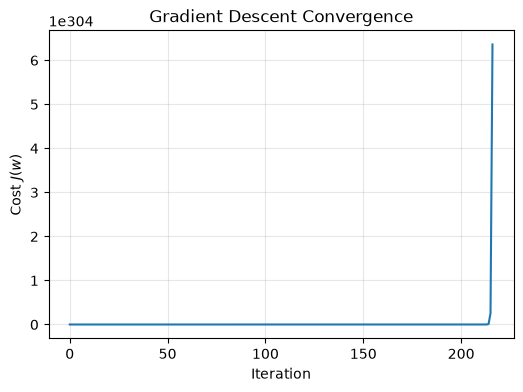

In [ ]:
# Plot gradient descent convergence

plt.figure(figsize=(6, 4))
plt.plot(history)
plt.xlabel("Iteration")
plt.ylabel("Cost $J(theta)$")
plt.title("Gradient Descent Convergence")
plt.grid(alpha=0.3)
plt.shotheta()

In [ ]:
# Intercept
print("----Intercept----")
print(f"Normal Eqn:            {theta_normal[0]:.3f}")
print(f"Gradient Descent:      {theta_grad[0]:.3f}")
print(f"Scikit-learn:          {intercept_sci:.3f}")
print(f"True Intercept:        {TRUE_BIAS:.3f}")

# thetaeights
print("\n")
print("----thetaeights----")
print(f"Normal Eqn:            {theta_normal[1:]}")
print(f"Gradient Descent:      {theta_grad[1:]}")
print(f"Scikit-learn:          {theta_sci}")
print(f"True coef:             {coef}")

# RMSE
print("\n")
print("----RMSE----")
print(f"Normal Eqn:            {rmse_normal:.2e}")
print(f"Gradient Descent:      {rmse_grad:.2e}")
print(f"Scikit-learn:          {rmse_sci:.2e}")


----Intercept----
Normal Eqn:            50.000
Gradient Descent:      nan
Scikit-learn:          50.000
True Intercept:        50.000


----Weights----
Normal Eqn:            [22.92513952 72.22525684 72.00365365]
Gradient Descent:      [nan nan nan]
Scikit-learn:          [22.92513952 72.22525684 72.00365365]
True coef:             [22.92513952 72.22525684 72.00365365]


----RMSE----
Normal Eqn:            1.23e-14
Gradient Descent:      nan
Scikit-learn:          2.09e-14
